# **Australian Solar Generation Forecasting**

## **Step 1: Environment Setup & Time Series Fundamentals**

**Research/Learn:**

*   **Time series forecasting** predicts future values using historical data, crucial for trend and seasonal analysis. **Univariate forecasting** uses a **single** variable's past to predict its future, while **multivariate** uses **multiple** interdependent variables. **Probabilistic forecasts** provide a **probability distribution** of potential future values, capturing uncertainty better than deterministic point forecasts.

*   **NASA POWER** (Source API docs: https://power.larc.nasa.gov/api/pages/#/) provides analysis-ready solar and meteorological time series for
energy applications. The Temporal API family includes **Hourly**, **Daily**, **Monthly**, and **Climatology** services. Of these, Hourly is the most useful for our energy optimization engine because it provides hour-by-hour values, while Daily is a strong fallback or simpler first integration. NASA’s Temporal overview also shows that Hourly supports Point only, while Daily, Monthly, and Climatology support both Point and Regional. For our system, NASA POWER is useful because it adds a real environmental layer
for:
    * solar generation modeling
    * battery charge/discharge simulation
    * EV charging optimization
    * TOU-aware cost simulation
    * stronger scenario confidence

*   **Australian postcode datasets** are geographical collections that link postcodes across Australia to their corresponding physical locations. These datasets are essential for spatial analysis and localized data retrieval in technical projects.

    * **Core Attributes:** Each record typically includes the 4-digit Australian postcode, suburb/locality names, state, and precise geographic coordinates (Latitude and Longitude).

    * **Data Formats:** These datasets are commonly available in open-standard formats such as CSV for tabular processing or GeoJSON for mapping and spatial queries.

In [ ]:
# install libraries ( transformers , datasets , gluonts , chronos , pandas , requests )
!pip install transformers datasets gluonts chronos pandas requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.7 MB/s eta 0:00:00
  Created wheel for chronos: filename=chronos-0.3-py3-none-any.whl size=7373 sha256=007221a0b2e016843461f581302bba4b192f7e3ac158283bb8636abac11a2c6b
  Stored in directory: /root/.cache/pip/wheels/b5/9c/d5/1dbbab8b167406e7058cf3c96fa031b98ef022b893a66c634a
Successfully built chronos


In [ ]:
# HF account
from huggingface_hub import HfApi

api = HfApi()

user_info = api.whoami()

user_info

{'type': 'user',
 'id': '68810e5b766eae4f6f2ac465',
 'name': 'codenhenhe',
 'fullname': 'Nguyễn Nhựt Linh',
 'email': 'linhnguyennhut07103@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1780272000,
 'isPro': False,
 'avatarUrl': '/avatars/029b932f62a41833fc86c6dac1282cda.svg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'solar-generation-forecasting',
   'role': 'write',
   'createdAt': '2026-05-06T03:31:37.355Z'}}}

In [ ]:
# HF token
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

print(type(HF_TOKEN))

<class 'str'>


In [ ]:
!curl --location 'https://power.larc.nasa.gov/api/temporal/daily/point?parameters=ALLSKY_SFC_SW_DWN%2CT2M&community=RE&longitude=114.852437&latitude=-27.832196&start=20160101&end=20260101&format=JSON'

{"type":"Feature","geometry":{"type":"Point","coordinates":[114.852,-27.832,246.59]},"properties":{"parameter":{"ALLSKY_SFC_SW_DWN":{"20160101":8.9544,"20160102":8.5466,"20160103":8.2236,"20160104":5.635,"20160105":5.394,"20160106":8.2738,"20160107":7.3625,"20160108":8.5915,"20160109":8.6011,"20160110":7.6752,"20160111":8.2174,"20160112":7.686,"20160113":7.6999,"20160114":7.2845,"20160115":8.028,"20160116":6.6989,"20160117":6.4668,"20160118":5.3532,"20160119":6.3754,"20160120":7.7167,"20160121":5.8301,"20160122":8.1257,"20160123":8.3906,"20160124":6.9996,"20160125":5.6066,"20160126":8.3916,"20160127":7.4777,"20160128":5.5296,"20160129":5.1797,"20160130":7.0231,"20160131":5.5678,"20160201":8.875,"20160202":8.9438,"20160203":8.9566,"20160204":8.9004,"20160205":8.8238,"20160206":8.7672,"20160207":8.7295,"20160208":8.7026,"20160209":8.5848,"20160210":8.5361,"20160211":8.4485,"20160212":8.3573,"20160213":8.2891,"20160214":8.3338,"20160215":8.0503,"20160216":7.4318,"20160217":7.6598,"2016021

In [ ]:
import requests
import pandas as pd

def get_coordinates(postcode):
    lookup_table = {
        "2000": {"lat": -33.86, "long": 151.21},
    }
    return lookup_table.get(postcode, None)

def fetch_nasa_data(lat, long, start_date="20200101", end_date="20200131"):
    url = f"https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN%2CT2M&community=RE&longitude={long}&latitude={lat}&start={start_date}&end={end_date}&format=JSON"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data['properties']['parameter'])
        return df
    else:
        return f"Error: {response.status_code}"

In [ ]:
postcode_test = "2000"
coords = get_coordinates(postcode_test)

if coords:
    print(f"Fetching data for Postcode {postcode_test} (Lat: {coords['lat']}, Lon: {coords['long']})...")
    result_df = fetch_nasa_data(coords['lat'], coords['long'])
    print(result_df)
else:
    print("Postcode không tồn tại trong hệ thống test.")

Fetching data for Postcode 2000 (Lat: -33.86, Lon: 151.21)...
            ALLSKY_SFC_SW_DWN    T2M
2020010100                0.0  20.19
2020010101                0.0  19.68
2020010102                0.0  19.38
2020010103                0.0  19.20
2020010104                0.0  19.19
...                       ...    ...
2020013119                0.0  25.12
2020013120                0.0  24.83
2020013121                0.0  24.65
2020013122                0.0  24.52
2020013123                0.0  24.34

[744 rows x 2 columns]


## **Step 2: Postcode to Lat/Long Mapping**

Link dataset: https://github.com/matthewproctor/australianpostcodes/blob/master/australian_postcodes.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_origin = pd.read_csv("/content/drive/MyDrive/TT/data/postcodes/australian_postcodes.csv")

In [ ]:
df_origin

,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
0,230,200,ANU,ACT,149.119000,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
1,21820,200,Australian National University,ACT,149.118900,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
2,232,800,DARWIN,NT,130.836680,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
3,24049,800,DARWIN CITY,NT,130.836680,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
4,233,801,DARWIN,NT,130.836680,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,NaN,Darwin,71000.0,Lingiari,Rural,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18554,11186,9013,BRISBANE,QLD,152.823141,-27.603479,CITY DC - BRISBANE,LVR,Updated 25-Mar-2020 SA3,30504.0,...,44.349792,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18555,11187,9015,BRISBANE,QLD,152.823141,-27.603479,CITY DC - BRISBANE,LVR,Updated 25-Mar-2020 SA3,30504.0,...,44.349792,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18556,11196,9464,NORTHGATE MC,QLD,153.074982,-27.397055,NaN,NaN,Updated 25-Mar-2020 SA3,30203.0,...,NaN,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18557,11197,9726,GOLD COAST MC,QLD,153.412197,-28.008783,NaN,NaN,Updated 25-Mar-2020 SA3,30910.0,...,NaN,Q1,PHN303,NaN,Gold Coast,33430.0,McPherson,NaN,NaN,NaN


In [ ]:
postcode_counts = (
    df_origin["postcode"]
    .value_counts()
    .reset_index()
)

postcode_counts.columns = ["postcode", "count"]

postcode_counts = postcode_counts.sort_values(
    "count",
    ascending=False
)

print(postcode_counts.head(20))

    postcode  count
0        822    111
1        872    110
2       4702    106
3       2795    103
4       2460     97
5       4871     92
6       4570     89
7       4352     79
8       2850     79
9       2480     75
10      2540     70
11      4740     69
12      2330     65
14      2469     64
13      4306     64
16      2650     62
15      3352     62
18      6532     59
17       852     59
19      2484     58


In [ ]:
df_origin[df_origin['postcode'] == 822]

,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
60,282,822,ACACIA HILLS,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
61,19980,822,ANGURUGU,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
62,19981,822,ANINDILYAKWA,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
63,19982,822,ANNIE RIVER,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
64,19983,822,BATHURST ISLAND,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,20053,822,WICKHAM,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
167,320,822,WINNELLIE,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
168,20054,822,WISHART,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 3-Dec-2022,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett
169,321,822,WOOLANING,NT,130.62543,-11.75842,Northern Territory Country 1,Delivery Area,Updated 6-Sep-2025,70205.0,...,15.858936,NT1,PHN701,Northern Territory,Palmerston,72800.0,Solomon,Inner Metropolitan,70024.0,Spillett


In [ ]:
df_main = df_origin.groupby('postcode')[['lat', 'long']].mean().reset_index()
df_main

,postcode,lat,long
0,200,-35.277700,149.118950
1,800,-12.458684,130.836680
2,801,-12.458684,130.836680
3,803,-12.433991,130.745908
4,804,-12.428017,130.873315
...,...,...,...
3170,9013,-27.603479,152.823141
3171,9015,-27.603479,152.823141
3172,9464,-27.397055,153.074982
3173,9726,-28.008783,153.412197


In [ ]:
def lat_long_mapping(postcode):
  res = df_main.loc[df_main['postcode'] == postcode, ['lat', 'long']]
  if not res.empty:
    return res['lat'].mean(), res['long'].mean()
  return None, None

In [ ]:
lat, long = lat_long_mapping(3000)

print(f"lat: {lat}")
print(f"long: {long}")

lat: -37.81443733
long: 144.9825846


## **Step 3: NASA POWER API Integration**

In [ ]:
postcode = 3000
lat, long = lat_long_mapping(postcode)

In [ ]:
import requests
import json
import os
from datetime import datetime
from dateutil.relativedelta import relativedelta

def fetch_and_save_nasa_data(postcode, lat, long, start_date=None, end_date=None, save_dir="data/raw"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Đã tạo thư mục: {save_dir}")

    if start_date is None or end_date is None:
        now = datetime.now()
        dt_end = now - relativedelta(days=1)
        dt_start = dt_end - relativedelta(months=24)

        if end_date is None:
            end_date = dt_end.strftime("%Y%m%d")
        if start_date is None:
            start_date = dt_start.strftime("%Y%m%d")

    url = (
        f"https://power.larc.nasa.gov/api/temporal/hourly/point?"
        f"parameters=T2M,ALLSKY_SFC_SW_DWN,WS10M&community=RE&longitude={long}&latitude={lat}"
        f"&start={start_date}&end={end_date}&format=JSON"
    )

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        file_path = os.path.join(save_dir, f"postcode_{postcode}.json")

        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        print(f"Thành công! Đã lưu tại: {file_path}")
        return data

    except requests.exceptions.RequestException as e:
        error_msg = f"Lỗi kết nối API cho postcode {postcode}: {e}"
        print(error_msg)
        return None

In [ ]:
data_auto = fetch_and_save_nasa_data(postcode, lat, long, save_dir="/content/drive/MyDrive/TT/data/raw")
data_auto

Đã tạo thư mục: /content/drive/MyDrive/TT/data/raw
Thành công! Đã lưu tại: /content/drive/MyDrive/TT/data/raw/postcode_3000.json


{'type': 'Feature',
 'geometry': {'type': 'Point', 'coordinates': [144.963, -37.814, 58.74]},
 'properties': {'parameter': {'T2M': {'2024050500': 10.97,
    '2024050501': 10.79,
    '2024050502': 10.73,
    '2024050503': 10.66,
    '2024050504': 10.49,
    '2024050505': 10.4,
    '2024050506': 10.3,
    '2024050507': 10.48,
    '2024050508': 12.26,
    '2024050509': 13.78,
    '2024050510': 15.27,
    '2024050511': 16.46,
    '2024050512': 17.25,
    '2024050513': 17.81,
    '2024050514': 17.98,
    '2024050515': 17.74,
    '2024050516': 16.91,
    '2024050517': 14.9,
    '2024050518': 14.0,
    '2024050519': 13.66,
    '2024050520': 13.25,
    '2024050521': 12.73,
    '2024050522': 12.12,
    '2024050523': 11.59,
    '2024050600': 11.12,
    '2024050601': 10.74,
    '2024050602': 10.43,
    '2024050603': 10.18,
    '2024050604': 10.04,
    '2024050605': 9.88,
    '2024050606': 9.74,
    '2024050607': 10.1,
    '2024050608': 12.69,
    '2024050609': 14.58,
    '2024050610': 15.97,
    

Đang tính toán Elbow Method, vui lòng đợi...


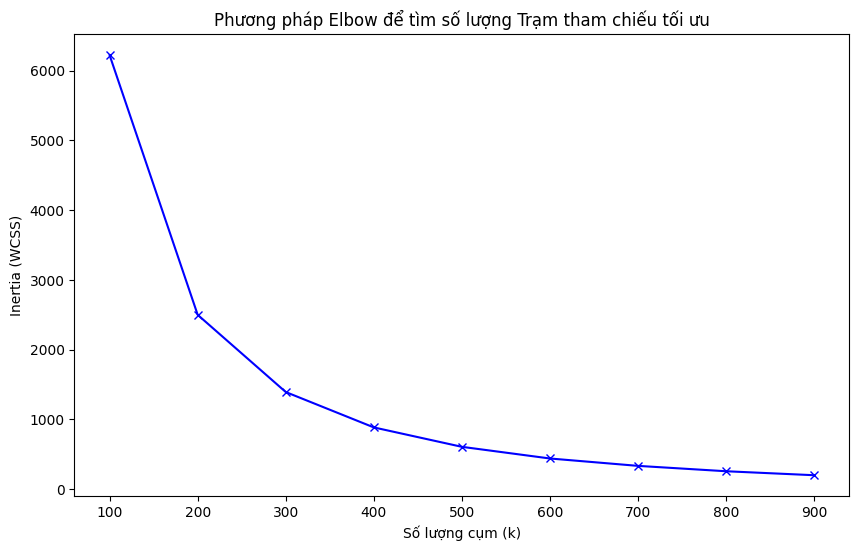

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/TT/data/postcodes/australian_postcodes.csv')

df_clean = df.dropna(subset=['lat', 'long'])
df_clean = df_clean[df_clean['type'] != 'PO Box'] # Tập trung vào khu vực dân cư
coords = df_clean[['lat', 'long']].values

print("Đang tính toán Elbow Method, vui lòng đợi...")
inertia = []
k_range = range(100, 901, 100) # Thử nghiệm từ 100 đến 900 trạm

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertia.append(km.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Phương pháp Elbow để tìm số lượng Trạm tham chiếu tối ưu')
plt.show()

In [ ]:
n_optimal = 500
print(f"Đang tiến hành phân cụm với k = {n_optimal}...")

kmeans = KMeans(n_clusters=n_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(coords)

# Tìm "Medoids" thực tế
reference_points = []
for i in range(n_optimal):
    cluster_points = df_clean[df_clean['cluster'] == i]
    center = kmeans.cluster_centers_[i]

    # Tính khoảng cách Euclidean
    distances = np.linalg.norm(cluster_points[['lat', 'long']].values - center, axis=1)
    closest_point_idx = distances.argmin()

    ref_point = cluster_points.iloc[closest_point_idx].copy()
    reference_points.append({
        'solar_ref_id': f'AUS_SOLAR_REF_{i:03d}',
        'lat': ref_point['lat'],
        'long': ref_point['long'],
        'state': ref_point['state'],
        'postcode': ref_point['postcode']
    })

df_ref_points = pd.DataFrame(reference_points)
# df_ref_points.to_csv('/content/volta_solar_reference_points.csv', index=False)

# print(f"Hoàn tất! Đã lưu {len(df_ref_points)} trạm tham chiếu.")

Đang tiến hành phân cụm với k = 500...


In [ ]:
df_mapping = df_clean[['postcode', 'lat', 'long', 'cluster']].copy()

df_mapping['solar_ref_id'] = df_mapping['cluster'].apply(lambda x: f'AUS_SOLAR_REF_{x:03d}')

# Lấy tọa độ của các trạm để so sánh
ref_coords = df_ref_points[['lat', 'long']].values
df_mapping['ref_lat'] = df_mapping['cluster'].apply(lambda x: ref_coords[x][0])
df_mapping['ref_long'] = df_mapping['cluster'].apply(lambda x: ref_coords[x][1])

df_mapping['distance_km'] = np.sqrt(
    (df_mapping['lat'] - df_mapping['ref_lat'])**2 +
    (df_mapping['long'] - df_mapping['ref_long'])**2
) * 111

# df_mapping.to_csv('/content/postcode_to_ref_mapping.csv', index=False)
print("Đã tạo xong file Mapping postcode!")

Đã tạo xong file Mapping postcode!


In [ ]:
import requests
import json
import os
import time
import pandas as pd

def fetch_nasa_daily_volta(ref_points_path, start_date = "20160101", end_date = "20251231", save_dir="/content/nasa_data_daily"):
    # 1. Tạo thư mục lưu trữ
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Đã tạo thư mục: {save_dir}")

    df_refs = pd.read_csv(ref_points_path)

    # Bức xạ, Nhiệt độ, Tốc độ gió, Độ ẩm
    params = "ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M"

    print(f"Bắt đầu tải dữ liệu cho {len(df_refs)} trạm...")

    for i, row in df_refs.iterrows():
        ref_id = row['solar_ref_id']
        lat = row['lat']
        lon = row['long']
        file_path = os.path.join(save_dir, f"{ref_id}.json")

        if os.path.exists(file_path):
            continue

        url = (
            f"https://power.larc.nasa.gov/api/temporal/daily/point?"
            f"parameters={params}&community=RE&longitude={lon}&latitude={lat}"
            f"&start={start_date}&end={end_date}&format=JSON"
        )

        try:
            response = requests.get(url, timeout=60)
            if response.status_code == 200:
                with open(file_path, 'w', encoding='utf-8') as f:
                    json.dump(response.json(), f, ensure_ascii=False)

                if (i + 1) % 10 == 0:
                    print(f"--- Đã tải xong {i + 1}/{len(df_refs)} trạm ---")

                # Nghỉ ngắn để không bị NASA chặn
                time.sleep(1.1)

            elif response.status_code == 429:
                print(f"Chạm giới hạn API tại {ref_id}, nghỉ 30s...")
                time.sleep(30)
            else:
                print(f"Lỗi {response.status_code} tại trạm {ref_id}")

        except Exception as e:
            print(f"Lỗi kết nối tại trạm {ref_id}: {e}")

    print(f"Hoàn tất! Tất cả file JSON nằm tại: {save_dir}")

# ref_points_path = "/content/drive/MyDrive/TT/data/volta_solar_reference_points.csv"
# json_dir = "/content/drive/MyDrive/TT/data/raw/daily/"

# fetch_nasa_daily_volta(ref_points_path, save_dir=json_dir)

Bắt đầu tải dữ liệu cho 500 trạm...
--- Đã tải xong 10/500 trạm ---
--- Đã tải xong 20/500 trạm ---
--- Đã tải xong 30/500 trạm ---
--- Đã tải xong 40/500 trạm ---
--- Đã tải xong 50/500 trạm ---
--- Đã tải xong 60/500 trạm ---
--- Đã tải xong 70/500 trạm ---
--- Đã tải xong 80/500 trạm ---
--- Đã tải xong 90/500 trạm ---
--- Đã tải xong 100/500 trạm ---
--- Đã tải xong 110/500 trạm ---
--- Đã tải xong 120/500 trạm ---
--- Đã tải xong 130/500 trạm ---
--- Đã tải xong 140/500 trạm ---
--- Đã tải xong 150/500 trạm ---
--- Đã tải xong 160/500 trạm ---
--- Đã tải xong 170/500 trạm ---
--- Đã tải xong 180/500 trạm ---
--- Đã tải xong 190/500 trạm ---
--- Đã tải xong 200/500 trạm ---
--- Đã tải xong 210/500 trạm ---
--- Đã tải xong 220/500 trạm ---
--- Đã tải xong 230/500 trạm ---
--- Đã tải xong 240/500 trạm ---
--- Đã tải xong 250/500 trạm ---
--- Đã tải xong 260/500 trạm ---
--- Đã tải xong 270/500 trạm ---
--- Đã tải xong 280/500 trạm ---
--- Đã tải xong 290/500 trạm ---
--- Đã tải xong 

In [ ]:
json_dir = "/content/drive/MyDrive/TT/data/raw/daily/"
ref_points_path = "/content/drive/MyDrive/TT/data/volta_solar_reference_points.csv"

import json
import os
import glob
import pandas as pd

def merge_nasa_json_to_csv(json_dir="/content/nasa_data_daily", output_file="/content/volta_master_daily.csv"):
    all_stations_data = []

    # Lấy danh sách tất cả các file .json trong thư mục
    json_files = glob.glob(os.path.join(json_dir, "*.json"))

    if not json_files:
        print("Không tìm thấy file JSON nào trong thư mục!")
        return

    print(f"Đang xử lý {len(json_files)} file JSON...")

    target_end_date = pd.to_datetime("2025-12-31")

    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            ref_id = os.path.basename(file_path).replace('.json', '')
            lat = data['geometry']['coordinates'][1]
            lon = data['geometry']['coordinates'][0]

            params_dict = data['properties']['parameter']

            df_station = pd.DataFrame(params_dict)

            df_station['date'] = pd.to_datetime(df_station.index, format='%Y%m%d')

            df_station = df_station[df_station['date'] <= target_end_date]

            # Thêm thông tin định danh trạm
            df_station['solar_ref_id'] = ref_id
            df_station['lat'] = lat
            df_station['long'] = lon

            all_stations_data.append(df_station)

        except Exception as e:
            print(f"Lỗi khi xử lý file {file_path}: {e}")

    # Nối tất cả các trạm thành một bảng tổng duy nhất
    if all_stations_data:
        master_df = pd.concat(all_stations_data, ignore_index=True)

        # Sắp xếp lại các cột cho dễ nhìn
        cols = ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M']
        master_df = master_df[cols]

        # Sắp xếp dữ liệu theo trạm và thời gian
        master_df = master_df.sort_values(['solar_ref_id', 'date'])

        # Lưu thành file CSV
        master_df.to_csv(output_file, index=False)
        print(f"Hoàn tất! Đã lưu file tổng.")
        return master_df
    else:
        print("Không có dữ liệu để gộp.")

# Gộp dữ liệu
master_df = merge_nasa_json_to_csv(json_dir=json_dir, output_file="/content/drive/MyDrive/TT/data/main/daily/raw.csv")

Đang xử lý 500 file JSON...
Hoàn tất! Đã lưu file tổng.


In [ ]:
daily_raw = pd.read_csv("/content/drive/MyDrive/TT/data/main/daily/raw.csv")
# Chuyển đổi cột date sang datetime
daily_raw['date'] = pd.to_datetime(daily_raw['date'])

print(daily_raw['date'].dtype)
daily_raw

datetime64[ns]


,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M
0,AUS_SOLAR_REF_000,2016-01-01,-27.832,114.852,8.9544,31.15,4.20,40.78
1,AUS_SOLAR_REF_000,2016-01-02,-27.832,114.852,8.5466,26.56,4.61,53.99
2,AUS_SOLAR_REF_000,2016-01-03,-27.832,114.852,8.2236,26.15,2.78,55.57
3,AUS_SOLAR_REF_000,2016-01-04,-27.832,114.852,5.6350,25.23,3.16,58.72
4,AUS_SOLAR_REF_000,2016-01-05,-27.832,114.852,5.3940,24.70,3.66,59.91
...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,-33.865,147.461,9.6631,19.30,2.33,41.20
1826496,AUS_SOLAR_REF_499,2025-12-28,-33.865,147.461,8.7079,21.64,3.20,37.60
1826497,AUS_SOLAR_REF_499,2025-12-29,-33.865,147.461,9.6110,24.35,1.99,34.56
1826498,AUS_SOLAR_REF_499,2025-12-30,-33.865,147.461,8.8459,27.43,1.90,27.50


In [ ]:
# Kiểm tra số lượng dòng của từng trạm
status_check = daily_raw.groupby('solar_ref_id').size()

print("Số dòng trung bình mỗi trạm:", status_check.mean())
print("Trạm có ít dữ liệu nhất:", status_check.min())
print("Trạm có nhiều dữ liệu nhất:", status_check.max())

Số dòng trung bình mỗi trạm: 3653.0
Trạm có ít dữ liệu nhất: 3653
Trạm có nhiều dữ liệu nhất: 3653


## Step 4: Feature Engineering & Solar Generation Calculation

### 1. Solar Power Output Formula ($P$)
(Documentation Link: https://docs.nlr.gov/docs/fy14osti/62641.pdf)

This formula is based on the NREL PVWatts v5 model, which is the industry standard for estimating the electricity production of photovoltaic (PV) systems.  $$P = C \times \frac{G}{1000} \times [1 + \gamma \times (T_{cell} - 25)] \times PR$$Parameters:
* $P$: Power output ($kWh$ for the given time interval).  
* $C$: Nameplate DC capacity of the system ($kWp$).  
* $G$: Incident solar radiation from NASA ($W/m^2$) — variable ALLSKY_SFC_SW_DWN.  
* $1000$: Reference irradiance at Standard Test Conditions (STC) ($W/m^2$).  
* $\gamma$: Temperature coefficient (typically $-0.004$ or $-0.4\%$ per $^\circ C$ for crystalline silicon panels).  
* $T_{cell}$: The actual temperature of the solar cells ($^\circ C$).  
* $25$: Reference cell temperature at STC ($^\circ C$).  
* $PR$: Performance Ratio (typically $0.75$ to $0.80$), accounting for system losses like inverter efficiency, wiring, and soiling.  

### 2. Cell Temperature Estimation Formula ($T_{cell}$)
Since NASA provides ambient air temperature ($T_{ambient}$), we use a simplified version of the Sandia National Laboratories model to estimate the cell temperature:  
$$T_{cell} = T_{ambient} + (G \times 0.025)$$

Parameters:
* $T_{ambient}$: Ambient air temperature at 2 meters from NASA
* ($^\circ C$) — variable T2M.  
* $0.025$: The heat absorption coefficient (Ross coefficient) for roof-mounted systems.  

### 3. Energy Calculation for 30-Minute Intervals
When performing Linear Interpolation to convert hourly NASA data into 30-minute intervals, the energy ($kWh$) generated in that 30-minute window must be adjusted because the original formula calculates power for a full hour:  
$$P_{30min} = \frac{P_{formula}}{2}$$
(Or multiply by $0.5$ hours to convert the instantaneous power into energy for that specific time step).  

In [ ]:
# Kiểm tra giá trị -999 trên toàn bộ DataFrame
error_mask = (daily_raw == -999) | (daily_raw == -999.0)

# Lấy ra các hàng có ít nhất một ô bị lỗi
rows_with_error = daily_raw[error_mask.any(axis=1)]

print(f"Tổng số hàng chứa giá trị lỗi -999: {len(rows_with_error)}")
print(rows_with_error.head())

Tổng số hàng chứa giá trị lỗi -999: 4
              solar_ref_id       date     lat     long  ALLSKY_SFC_SW_DWN  \
105936   AUS_SOLAR_REF_028 2025-12-31 -18.451  137.607             -999.0   
1161653  AUS_SOLAR_REF_317 2025-12-31 -17.956  138.862             -999.0   
1263937  AUS_SOLAR_REF_345 2025-12-31 -13.643  136.947             -999.0   
1779010  AUS_SOLAR_REF_486 2025-12-31 -15.228  134.083             -999.0   

           T2M  WS2M   RH2M  
105936   26.96  3.07  76.22  
1161653  28.96  2.12  73.32  
1263937  28.93  5.06  82.92  
1779010  28.98  2.83  74.72  


In [ ]:
import numpy as np

# Thay -999 bằng NaN
daily_raw['ALLSKY_SFC_SW_DWN'] = daily_raw['ALLSKY_SFC_SW_DWN'].replace([-999, -999.0], np.nan)

# Nội suy gom nhóm ngắn gọn
daily_raw['ALLSKY_SFC_SW_DWN'] = daily_raw.groupby('solar_ref_id')['ALLSKY_SFC_SW_DWN'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

In [ ]:
# Kiểm tra lại giá trị -999 trên toàn bộ DataFrame
error_mask = (daily_raw == -999) | (daily_raw == -999.0)

# Lấy ra các hàng có ít nhất một ô bị lỗi
rows_with_error = daily_raw[error_mask.any(axis=1)]

print(f"Tổng số hàng chứa giá trị lỗi -999: {len(rows_with_error)}")
print(rows_with_error.head())

Tổng số hàng chứa giá trị lỗi -999: 0
Empty DataFrame
Columns: [solar_ref_id, date, lat, long, ALLSKY_SFC_SW_DWN, T2M, WS2M, RH2M]
Index: []


In [ ]:
import pandas as pd
import numpy as np

def solar_gen_calculation(master_df, capacity_kwp=6.6):

    df = master_df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # 1. Các hệ số mặc định (Default Assumptions)
    pr = 0.80             # Performance Ratio
    temp_coeff = -0.0035  # Temperature derate coeff

    # 2. Tính nhiệt độ tấm pin (T_cell)
    # Ước tính: T_cell = T_ambient + (Bức xạ * hệ số truyền nhiệt)
    # Vì là dữ liệu ngày, hệ số 2.5 là mức trung bình an toàn
    df['T_cell'] = df['T2M'] + (df['ALLSKY_SFC_SW_DWN'] * 2.5)

    # 3. Tính Temperature Derate
    # Dùng mốc 25 độ C làm chuẩn
    df['temp_factor'] = 1 + temp_coeff * (df['T_cell'] - 25)

    # 4. Công thức tính sản lượng điện (Daily kWh)
    # solar_gen = irradiance * system_size * orientation(1) * tilt(1) * shading(1) * temp_factor * PR
    df['solar_gen_kwh'] = (
        df['ALLSKY_SFC_SW_DWN'] * # Irradiance (kWh/m2/day)
        capacity_kwp * # System size
        1.0 * # Orientation factor (North)
        1.0 * # Tilt factor
        df['temp_factor'] * # Temperature derate
        pr                         # Performance ratio
    )

    # Đảm bảo không có giá trị âm
    df['solar_gen_kwh'] = df['solar_gen_kwh'].clip(lower=0)

    # 5. Thêm các đặc trưng thời gian để huấn luyện Chronos
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month

    return df

processed_df = solar_gen_calculation(daily_raw, capacity_kwp=6.6)

# Lưu file kết quả cuối cùng
processed_df.to_csv("/content/drive/MyDrive/TT/data/main/daily/main.csv", index=False)


In [ ]:
processed_df

,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,T_cell,temp_factor,solar_gen_kwh,day_of_year,month
0,AUS_SOLAR_REF_000,2016-01-01,-27.832,114.852,8.9544,31.15,4.20,40.78,53.53600,0.900124,42.557171,1,1
1,AUS_SOLAR_REF_000,2016-01-02,-27.832,114.852,8.5466,26.56,4.61,53.99,47.92650,0.919757,41.505010,2,1
2,AUS_SOLAR_REF_000,2016-01-03,-27.832,114.852,8.2236,26.15,2.78,55.57,46.70900,0.924018,40.121445,3,1
3,AUS_SOLAR_REF_000,2016-01-04,-27.832,114.852,5.6350,25.23,3.16,58.72,39.31750,0.949889,28.261850,4,1
4,AUS_SOLAR_REF_000,2016-01-05,-27.832,114.852,5.3940,24.70,3.66,59.91,38.18500,0.953852,27.166024,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,-33.865,147.461,9.6631,19.30,2.33,41.20,43.45775,0.935398,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,-33.865,147.461,8.7079,21.64,3.20,37.60,43.40975,0.935566,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,-33.865,147.461,9.6110,24.35,1.99,34.56,48.37750,0.918179,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,-33.865,147.461,8.8459,27.43,1.90,27.50,49.54475,0.914093,42.693967,364,12


In [ ]:
print(processed_df.isnull().sum())

solar_ref_id         0
date                 0
lat                  0
long                 0
ALLSKY_SFC_SW_DWN    0
T2M                  0
WS2M                 0
RH2M                 0
T_cell               0
temp_factor          0
solar_gen_kwh        0
day_of_year          0
month                0
dtype: int64


In [ ]:
from scipy import stats

# Tính Z-score cho sản lượng điện
z_scores = stats.zscore(processed_df['solar_gen_kwh'])
# Tìm các dòng có độ lệch chuẩn > 3 (nghi ngờ là outlier)
outliers = processed_df[np.abs(z_scores) > 3]
print(f"Số lượng dòng nghi ngờ outlier: {len(outliers)}")

Số lượng dòng nghi ngờ outlier: 0


## Step 5: Synthetic / Augmented Data Handling

In [ ]:
from datasets import Dataset, DatasetDict

# Chia dữ liệu theo thời gian (Time-based split)
train_df = processed_df[processed_df['date'] < '2023-01-01']
val_df = processed_df[(processed_df['date'] >= '2023-01-01') & (processed_df['date'] < '2024-01-01')]
test_df = processed_df[processed_df['date'] >= '2024-01-01']

# Chuyển sang định dạng Hugging Face Dataset
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

NameError: name 'processed_df' is not defined

In [ ]:
# Đẩy lên Hugging Face Hub
dataset_dict.push_to_hub(
    repo_id="codenhenhe/volta-solar-daily-v1",
    token=HF_TOKEN
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1279 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   1%|          |  615kB / 83.9MB            

...

Creating parquet from Arrow format:   0%|          | 0/366 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  19%|#9        | 4.47MB / 23.4MB            

CommitInfo(commit_url='https://huggingface.co/datasets/codenhenhe/volta-solar-daily-v1/commit/70b050faed0ce877b2d7e0c07583e98a0b8bfcc7', commit_message='Upload dataset', commit_description='', oid='70b050faed0ce877b2d7e0c07583e98a0b8bfcc7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/codenhenhe/volta-solar-daily-v1', endpoint='https://huggingface.co', repo_type='dataset', repo_id='codenhenhe/volta-solar-daily-v1'), pr_revision=None, pr_num=None)

## **Step 6: Research Open-Source Time Series Models on HF**

### **1. Candidate Models Overview**

#### **A. Amazon Chronos-2**
Chronos-2 is a state-of-the-art foundation model for time series forecasting, evolving from the original T5-based architecture. It treats time-series data as a language-modeling task but with significant upgrades for multivariate support.

* **Key Strength:** Native support for multivariate data and exogenous covariates (e.g., Temperature, Irradiance).
* **Architecture:** Encoder-only Transformer (v2).
* **Probabilistic:** High-quality P10, P50, and P90 intervals.

#### **B. Salesforce MOIRAI-2.0-R (small)**
The Masked Encoder-based Universal Time Series Forecasting Transformer (MOIRAI) version 2.0-R is designed for high-performance regression.

* **Key Strength:** Designed for "Any-variate" forecasting. The 2.0-R (Regression) version is specifically optimized for continuous values like solar power output.
* **Architecture:** Decoder-only Transformer with a focus on long-context understanding.
* **Efficiency:** Very compact (approx. 11.4M parameters) but matches the performance of much larger models.

#### **C. IBM Granite TinyTimeMixer (TTM-r1)**
Part of the IBM Granite family, TTM is a "Tiny" yet powerful model optimized for speed and efficiency in multivariate forecasting.

* **Key Strength:** Extremely lightweight (<1M parameters). It uses a "Mixer" architecture that is exceptionally good at cross-channel correlation (learning how Temperature affects Solar Output).
* **Real-time Readiness:** Ideal for edge computing or low-latency web applications.


### **2. Pros & Cons Analysis for Multivariate Solar Data**

| Model | Pros | Cons |
| :--- | :--- | :--- |
| **Chronos-2** | Excellent zero-shot generalization; industry-standard for uncertainty (P10-P90). | Slightly higher latency compared to Tiny models. |
| **MOIRAI-2.0-R** | Superior handling of complex non-linear relationships in weather data. | Requires specific libraries (`uni2ts`) for optimal performance. |
| **Granite TTM** | Minimal VRAM usage; exceptionally fast inference for real-time apps. | May require more context length to capture long-term seasonal patterns. |

---

### **Prepare benchmark data**

In [ ]:
import time
import pandas as pd
import numpy as np

full_data_path = "/content/drive/MyDrive/TT/data/main/daily/main.csv"

full_data = pd.read_csv(full_data_path, parse_dates=["date"])
full_data

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TT/data/main/daily/main.csv'

In [ ]:
full_data = full_data.drop(columns=["lat", "long"])
full_data

In [ ]:
# Lấy dữ liệu 5 cuối

benchmark_data = full_data[full_data['date'] >= '2021-01-01']
benchmark_data


In [ ]:
benchmark_years = [2023, 2024, 2025]

benchmark_windows = {}

for year in benchmark_years:

    print(f"Preparing data for {year}")

    # FORECAST WINDOW
    forecast_start = pd.Timestamp(
        f"{year}-01-01"
    )

    forecast_end = (
        forecast_start
        + pd.Timedelta(days=364)
    )

    # CONTEXT WINDOW
    context_end = (
        forecast_start
        - pd.Timedelta(days=1)
    )

    context_start = (
        context_end
        - pd.Timedelta(days=729)
    )

    # CONTEXT DATA
    train_data = benchmark_data[
        (benchmark_data["date"] >= context_start)
        &
        (benchmark_data["date"] <= context_end)
    ].copy()

    # FUTURE DATA
    future_data = benchmark_data[
        (benchmark_data["date"] >= forecast_start)
        &
        (benchmark_data["date"] <= forecast_end)
    ].copy()

    # VERIFY
    train_lengths = (
        train_data
        .groupby("solar_ref_id")
        .size()
    )

    future_lengths = (
        future_data
        .groupby("solar_ref_id")
        .size()
    )

    assert (train_lengths == 730).all()
    assert (future_lengths == 365).all()

    # STORE

    benchmark_windows[year] = {

        "train_data": train_data,

        "future_data": future_data,

        "future_covariates": future_data.drop(
            columns=["solar_gen_kwh"]
        )
    }

### **Model 1: amazon/chronos-2**

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.8 MB/s eta 0:00:00


In [ ]:
from chronos import Chronos2Pipeline

chronos = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Generate predictions with covariates
# pred_df = pipeline.predict_df(
#     train_data,
#     future_df=future_data,
#     prediction_length=365,  # Number of steps to forecast
#     quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
#     id_column="solar_ref_id",  # Column identifying different time series
#     timestamp_column="date",  # Column with datetime information
#     target="solar_gen_kwh",  # Column(s) with time series values to predict
# )

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [ ]:
chronos_all_predictions = []

for year in benchmark_years:

    print(f"\nChronos Forecast {year}")


    # LOAD PREPARED DATA
    train_data = benchmark_windows[year][
        "train_data"
    ]

    future_data = benchmark_windows[year][
        "future_data"
    ]

    future_covariates = benchmark_windows[
        year
    ][
        "future_covariates"
    ]


    # PREDICT
    pred_df = chronos.predict_df(
        train_data,
        future_df=future_covariates,
        prediction_length=365,

        quantile_levels=[
            0.1,
            0.5,
            0.9
        ],

        id_column="solar_ref_id",
        timestamp_column="date",
        target="solar_gen_kwh",
    )


    # STANDARDIZED RESULT DF
    result_df = pd.DataFrame({

        "solar_ref_id": future_data[
            "solar_ref_id"
        ].values,

        "date": future_data[
            "date"
        ].values,

        # ground truth
        "solar_gen_kwh": future_data[
            "solar_gen_kwh"
        ].values,

        # quantile forecasts
        "0.1": pred_df["0.1"].values,
        "0.5": pred_df["0.5"].values,
        "0.9": pred_df["0.9"].values,

        "forecast_year": year,

        "model": "Chronos2"
    })

    chronos_all_predictions.append(result_df)

# CONCAT
chronos_all_predictions = pd.concat(
    chronos_all_predictions,
    ignore_index=True
)


Chronos Forecast 2023

Chronos Forecast 2024

Chronos Forecast 2025


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# QUANTILE LOSS
def quantile_loss(
    y_true,
    y_pred,
    q
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    errors = y_true - y_pred

    return 2 * np.maximum(
        q * errors,
        (q - 1) * errors
    ).mean()

# MAIN EVALUATION FUNCTION
def evaluate_forecasts(
    pred_df,
    target_col="solar_gen_kwh",
    median_col="0.5",
    quantile_columns=None
):

    # PREPARE
    y_true = pred_df[target_col].values
    y_pred = pred_df[median_col].values

    # POINT METRICS
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )

    smape = (
        100
        * np.mean(
            2
            * np.abs(y_pred - y_true)
            / (
                np.abs(y_true)
                + np.abs(y_pred)
                + 1e-8
            )
        )
    )

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape
    }

    # QUANTILE METRICS
    if quantile_columns is not None:

        q_losses = []

        for q_col in quantile_columns:

            if q_col not in pred_df.columns:
                continue

            q = float(q_col)

            q_loss = quantile_loss(
                y_true,
                pred_df[q_col].values,
                q
            )

            results[f"QL_{q_col}"] = q_loss

            q_losses.append(q_loss)

        if len(q_losses) > 0:

            results["CRPS"] = np.mean(
                q_losses
            )

    return pd.Series(results)

In [ ]:
# GLOBAL METRICS
chronos_global_metrics = evaluate_forecasts(
    pred_df=chronos_all_predictions,
    quantile_columns=["0.1", "0.5", "0.9"]
)

print("\nGLOBAL METRICS")
print(chronos_global_metrics)

# PER STATION METRICS
chronos_per_station_metrics = (
    chronos_all_predictions
    .groupby("solar_ref_id")
    .apply(
        lambda x: evaluate_forecasts(
            pred_df=x,
            quantile_columns=["0.1", "0.5", "0.9"]
        ),
        include_groups=False
    )
    .reset_index()
)

print("\nPER STATION METRICS")
print(chronos_per_station_metrics.head())


GLOBAL METRICS
MAE       0.496545
RMSE      0.635841
MAPE      0.023331
sMAPE     2.315074
QL_0.1    0.229413
QL_0.5    0.496545
QL_0.9    0.229269
CRPS      0.318409
dtype: float64

PER STATION METRICS
        solar_ref_id       MAE      RMSE      MAPE     sMAPE    QL_0.1  \
0  AUS_SOLAR_REF_000  0.518260  0.639087  0.020409  2.049517  0.206344   
1  AUS_SOLAR_REF_001  0.545685  0.694942  0.028401  2.791571  0.244840   
2  AUS_SOLAR_REF_002  0.560561  0.708593  0.027006  2.684746  0.257048   
3  AUS_SOLAR_REF_003  0.359946  0.466456  0.014083  1.400308  0.184223   
4  AUS_SOLAR_REF_004  0.290231  0.379447  0.013007  1.292335  0.127364   

     QL_0.5    QL_0.9      CRPS  
0  0.518260  0.215359  0.313321  
1  0.545685  0.277605  0.356043  
2  0.560561  0.258204  0.358605  
3  0.359946  0.167485  0.237218  
4  0.290231  0.147623  0.188406  


### **Model 2: google/timesfm-2.5-200m-pytorch**

In [ ]:
!pip install git+https://github.com/google-research/timesfm.git

  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-req-build-osn2ouje
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-req-build-osn2ouje
  Encountered 4 file(s) that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm.git to commit d720daa6786539c2566a44464fbda1019c0a82c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=44486 sha256=523c91e677d4198611b0e8ffb59bb9f039f

In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [ ]:
import numpy as np
import pandas as pd
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    torch_compile=True
)

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=365,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

In [ ]:
timesfm_all_predictions = []

# QUANTILE DETECTION
def detect_quantile_map(sample_q):
    """
    Detect correct quantile indices instead of hardcoding.
    """
    q = np.array(sample_q)

    # heuristic: median is usually central value
    median_idx = q.shape[-1] // 2

    # assume symmetric ordering
    q10_idx = 0
    q90_idx = -1

    return q10_idx, median_idx, q90_idx

# MAIN LOOP
for year in benchmark_years:

    print(f"\nTimesFM Forecast {year}")

    train_data = benchmark_windows[year]["train_data"]
    future_data = benchmark_windows[year]["future_data"]


    # BUILD SERIES MAP
    series_map = (
        train_data
        .sort_values("date")
        .groupby("solar_ref_id")["solar_gen_kwh"]
        .apply(lambda x: x.values)
        .to_dict()
    )

    future_map = (
        future_data
        .sort_values("date")
        .groupby("solar_ref_id")["solar_gen_kwh"]
        .apply(lambda x: x.values)
        .to_dict()
    )

    future_date_map = (
        future_data
        .sort_values("date")
        .groupby("solar_ref_id")["date"]
        .apply(lambda x: x.values)
        .to_dict()
    )


    # NORMALIZATION
    inputs = []
    ids = []
    scalers = {}

    for sid, series in series_map.items():

        if len(series) != 730:
            continue

        series = np.array(series, dtype=np.float32)

        mean = series.mean()
        std = series.std() + 1e-8

        norm_series = (series - mean) / std

        inputs.append(norm_series)
        ids.append(sid)

        scalers[sid] = (mean, std)


    # FORECAST
    point, quantiles = model.forecast(
        horizon=365,
        inputs=inputs
    )

    # detect quantile mapping once
    q10_idx, q50_idx, q90_idx = detect_quantile_map(quantiles[0, 0, :])

    # BUILD OUTPUT
    for i, sid in enumerate(ids):

        mean, std = scalers[sid]

        # denormalize predictions
        q10 = quantiles[i, :, q10_idx] * std + mean
        q50 = quantiles[i, :, q50_idx] * std + mean
        q90 = quantiles[i, :, q90_idx] * std + mean

        result_df = pd.DataFrame({
            "solar_ref_id": sid,
            "date": future_date_map[sid],

            "solar_gen_kwh": future_map[sid],

            "0.1": q10,
            "0.5": q50,
            "0.9": q90,

            "forecast_year": year,
            "model": "TimesFM2.5"
        })

        timesfm_all_predictions.append(result_df)


timesfm_all_predictions = pd.concat(
    timesfm_all_predictions,
    ignore_index=True
)


TimesFM Forecast 2023

TimesFM Forecast 2024

TimesFM Forecast 2025


In [ ]:
timesfm_global_metrics = evaluate_forecasts(
    pred_df=timesfm_all_predictions,
    quantile_columns=["0.1", "0.5", "0.9"]
)

print("\nGLOBAL METRICS")
print(timesfm_global_metrics)

results = []

for sid, df in timesfm_all_predictions.groupby("solar_ref_id"):
    res = evaluate_forecasts(
        pred_df=df,
        quantile_columns=["0.1", "0.5", "0.9"]
    )
    res["solar_ref_id"] = sid
    results.append(res)

timesfm_per_station_metrics = pd.DataFrame(results)

print("\nPER STATION METRICS")
print(timesfm_per_station_metrics.head())


GLOBAL METRICS
MAE        4.420362
RMSE       6.480145
MAPE       0.250101
sMAPE     18.461431
QL_0.1     5.296615
QL_0.5     4.420362
QL_0.9     1.494923
CRPS       3.737300
dtype: float64

PER STATION METRICS
        MAE      RMSE      MAPE      sMAPE    QL_0.1    QL_0.5    QL_0.9  \
0  3.061275  4.757808  0.147224  11.668764  3.998523  3.061275  0.981661   
1  5.726440  7.856044  0.371694  25.466040  6.935676  5.726440  1.890702   
2  4.562213  6.654838  0.277197  20.056909  5.388850  4.562213  1.523410   
3  4.140426  6.062016  0.186540  14.714307  5.220509  4.140426  1.384310   
4  4.028735  5.419499  0.215935  16.743331  4.725473  4.028735  1.402892   

       CRPS       solar_ref_id  
0  2.680486  AUS_SOLAR_REF_000  
1  4.850940  AUS_SOLAR_REF_001  
2  3.824824  AUS_SOLAR_REF_002  
3  3.581748  AUS_SOLAR_REF_003  
4  3.385700  AUS_SOLAR_REF_004  


In [ ]:
benchmark_data["solar_gen_kwh"].describe()

,solar_gen_kwh
count,913000.000000
mean,26.623877
std,10.174757
min,0.978336
25%,18.736821
50%,26.634798
75%,34.803250
max,50.002612


In [ ]:
timesfm_all_predictions["0.5"].describe()
# chronos_all_predictions["0.5"].describe()

,0.5
count,547500.000000
mean,28.939074
std,8.709086
min,6.517743
25%,22.040486
50%,29.488523
75%,36.257041
max,45.312904


### **Model 3: ibm-granite/granite-timeseries-ttm-r2**

In [1]:
!pip install git+https://github.com/google-research/timesfm
!pip install transformers accelerate

  Cloning https://github.com/google-research/timesfm to /tmp/pip-req-build-enyq2vjf
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm /tmp/pip-req-build-enyq2vjf
  Encountered 4 file(s) that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm to commit d720daa6786539c2566a44464fbda1019c0a82c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=44486 sha256=e530b90658c4a48fd96d0ddb0c77017e37cc6e4767d541e

In [3]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 85.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
from transformers import AutoModelForCausalLM
import torch

model = AutoModelForCausalLM.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    trust_remote_code=True
)

series = torch.tensor(train_series, dtype=torch.float32)

output = model.predict(
    context=series,
    horizon=365
)

ValueError: The checkpoint you are trying to load has model type `tinytimemixer` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`

In [ ]:
pred_df = []

for sid, group in train_data.groupby("solar_ref_id"):

    series = group.sort_values("date")["solar_gen_kwh"].values

    forecast = model.predict(
        context=torch.tensor(series),
        horizon=365
    )

    pred_df.append(...)